# Computer Exercise 15.13 — Problem 1
## MLP + ReLU 신경망 파라미터화의 안정화: target network · gradient clipping

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.13
> **날짜**: Day 80
> **언어**: Python 3 (NumPy / pandas / Matplotlib, 신경망 프레임워크 미사용 — 수기 backprop)

## 1. 문제 (원문)

> **Neural-network scaling of scalar Q-learning: target networks and gradient clipping.**
> Day 79 (§15.12) Problem 3 demonstrated that on a *slippery* 6×6 GridWorld with **linear function
> approximation** ($D_\phi = 13$ row/col one-hot + bias), scalar Q-learning converges cleanly
> because the feature map is fixed. §15.13 replaces the linear head with a **two-layer MLP with
> ReLU activation** $Q_\theta(s,a) = W_2\,\text{ReLU}(W_1\phi(s) + b_1)_a + b_2$, exposing the
> two classic instabilities of neural Q-learning: (i) the *moving target* problem — the
> bootstrap target $y = r + \gamma\max_{a'} Q_\theta(s', a')$ uses the same weights being
> updated, coupling the target to the prediction and producing oscillation / divergence;
> (ii) the *outlier-gradient* problem — a single high-magnitude TD-error propagates through
> the network as a large weight update, disproportionately shifting predictions elsewhere.
> Introduce (a) a **target network** $Q_{\theta^-}$ hard-updated every $K$ steps and
> (b) **gradient clipping** at threshold $\|g\|_2 \le c$, and quantify the marginal
> stabilization each contributes on a **continuous-state MountainCar-lite** environment.

### 한국어 풀이용 정리
Day 79 는 linear (고정 특징) 위에서 QR/IQN/Rainbow-lite 를 비교했고, 이번 §15.13 은 그 위계를
**MLP + ReLU** (특징이 학습되는) 로 이행했을 때 나타나는 두 가지 새 병리 — **움직이는 표적**
과 **outlier gradient** — 를 정면으로 다룬다. 세 조건 (A) plain MLP, (B) MLP + target network,
(C) MLP + target + gradient clipping 을 continuous 상태의 MountainCar-lite 환경에서 4 시드로
비교한다. 목표는 "이 두 stabilizer 없이는 왜 MLP Q-학습이 실패하는지" 를 정량 보이고, 두
요소가 각각 어느 지점에서 이득을 만드는지 분해하는 것이다.

## 2. 수학적 배경

### 2.1 MLP + ReLU 순전파
2-층 MLP 는
$$
h = \mathrm{ReLU}(W_1 s + b_1) \in \mathbb{R}^H, \qquad
Q_\theta(s, \cdot) = W_2 h + b_2 \in \mathbb{R}^{|\mathcal{A}|}.
$$
여기서 $s \in \mathbb{R}^{d_s}$ 는 원시 상태(스케일링만 적용), $H$ 는 은닉 폭.
파라미터는 $\theta = \{W_1, b_1, W_2, b_2\}$, 총 $d_s H + H + H |\mathcal{A}| + |\mathcal{A}|$ 개.

### 2.2 Q-학습 손실과 이동 표적
$(s_t, a_t, r_t, s_{t+1})$ 전이에 대해 표적은
$$
y_t \;=\; r_t + \gamma \max_{a'} Q_{\theta^-}(s_{t+1}, a')
$$
이고, 손실은 $L(\theta) = \tfrac12 (y_t - Q_\theta(s_t, a_t))^2$.
$\theta^- = \theta$ 로 두면 **표적과 예측이 같은 파라미터를 공유**해 gradient descent 는
$Q_\theta(s_t,a_t)$ 를 낮추는 방향으로 이동하는데 이 이동이 $Q_\theta(s_{t+1},a')$ 도 함께
바꿔 표적이 도망간다. 표적을 지연 파라미터 $\theta^-$ 로 고정하면 (매 $K$ 스텝마다 hard
copy: $\theta^- \leftarrow \theta$) 이 결합이 끊어져 회귀 문제로 환원된다.

### 2.3 Backprop 수기 유도
$\delta_t = y_t - Q_\theta(s_t, a_t)$ (TD-error), $e_a$ 는 $a_t$-번째 표준기저.
$$
\frac{\partial L}{\partial W_2} = -\delta_t\, e_a h^\top,\quad
\frac{\partial L}{\partial b_2} = -\delta_t\, e_a,\quad
\frac{\partial L}{\partial W_1} = -\delta_t\, (W_2^\top e_a \odot \mathbb{1}_{h>0})\, s^\top,\quad
\frac{\partial L}{\partial b_1} = -\delta_t\, W_2^\top e_a \odot \mathbb{1}_{h>0}.
$$

### 2.4 Gradient clipping (global $\ell_2$)
$g = \nabla_\theta L$ 벡터화, $\|g\|_2 > c$ 이면 $g \leftarrow g \cdot c / \|g\|_2$.
$$
\boxed{\;\hat g_t \;=\; g_t \cdot \min\!\left(1,\; \tfrac{c}{\|g_t\|_2}\right)\;}
$$
이는 outlier TD-error 로 인한 폭발적 업데이트를 잘라 학습 궤적의 분산을 억제한다.

## 3. 풀이 흐름

1. **환경**: MountainCar-lite. 상태 $s = (x, v)$, $x \in [-1.2, 0.6]$, $v \in [-0.07, 0.07]$.
   행동 $a \in \{-1, 0, +1\}$ (좌 · 무동력 · 우). 동역학
   $v' = v + 0.001 a - 0.0025\cos(3x)$, $x' = \mathrm{clip}(x + v', -1.2, 0.6)$.
   시작 $x_0 \sim \mathcal{U}[-0.5, -0.3]$, $v_0 = 0$. 목표 $x \ge 0.5$. 보상 $-1$ 매 스텝.
   최대 스텝 300.
2. **특징 정규화**: $\tilde s = ((x + 1.2)/1.8, (v + 0.07)/0.14)$ 로 $[0,1]^2$ 스케일링.
3. **MLP**: 입력 2, 은닉 16 (ReLU), 출력 3 (행동별 Q). Xavier 초기화.
4. **학습**: online SGD ($\alpha = 0.05$), $\varepsilon = 0.15$, $\gamma = 0.99$.
5. **조건**: (A) plain MLP ($\theta^- = \theta$, no clip), (B) MLP + target net (hard copy 매
   $K = 40$ 스텝), (C) MLP + target + gradient clip $c = 10.0$.
6. **평가지표**: 에피소드 길이 (짧을수록 좋음, 200 = truncation), tail-20 평균, 학습 궤적의
   변동 (episode length std, 즉 "얼마나 흔들리는가").
7. **실행**: 시드 4 개, 60 에피소드. 조건 3 개.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ── 환경: MountainCar-lite (continuous state) ─────────────────────────
def env_reset(rng):
    return np.array([rng.uniform(-0.5, -0.3), 0.0])

def env_step(s, a_idx):
    action = a_idx - 1  # {-1, 0, +1}
    x, v = s
    v = v + 0.007 * action - 0.0025 * np.cos(3*x)
    v = np.clip(v, -0.07, 0.07)
    x = np.clip(x + v, -1.2, 0.6)
    if x <= -1.2: v = 0.0
    done = (x >= 0.5)
    return np.array([x, v]), -1.0, done

def norm(s):
    return np.array([(s[0] + 1.2)/1.8, (s[1] + 0.07)/0.14])

MAX_STEPS = 300
DS, H, NA = 2, 16, 3
GAMMA = 0.99

# ── MLP + ReLU 수기 backprop ──────────────────────────────────────────
def init_mlp(rng, ds=DS, h=H, na=NA):
    W1 = rng.normal(0, np.sqrt(2/ds), (h, ds))
    b1 = np.zeros(h)
    W2 = rng.normal(0, np.sqrt(2/h), (na, h))
    b2 = np.zeros(na)
    return dict(W1=W1, b1=b1, W2=W2, b2=b2)

def forward(theta, s):
    z = theta['W1'] @ s + theta['b1']
    h = np.maximum(z, 0.0)
    q = theta['W2'] @ h + theta['b2']
    return q, h

def grad_step(theta, s, a, y, alpha, clip=None):
    q, h = forward(theta, s)
    delta = y - q[a]
    ea = np.zeros(NA); ea[a] = 1.0
    gW2 = -delta * np.outer(ea, h)
    gb2 = -delta * ea
    dh = -delta * theta['W2'][a]
    dz = dh * (h > 0)
    gW1 = np.outer(dz, s)
    gb1 = dz
    if clip is not None:
        flat = np.concatenate([gW1.ravel(), gb1.ravel(), gW2.ravel(), gb2.ravel()])
        gn = np.linalg.norm(flat)
        if gn > clip:
            scale = clip / gn
            gW1 *= scale; gb1 *= scale; gW2 *= scale; gb2 *= scale
    theta['W1'] -= alpha * gW1
    theta['b1'] -= alpha * gb1
    theta['W2'] -= alpha * gW2
    theta['b2'] -= alpha * gb2
    return abs(delta)

def copy_theta(t):
    return {k: v.copy() for k, v in t.items()}

def run_scalar(seed, mode='plain', n_ep=60, alpha=0.05, eps=0.20,
               target_period=20, clip=None):
    rng = np.random.default_rng(seed)
    theta = init_mlp(rng)
    theta_tar = copy_theta(theta) if mode != 'plain' else theta
    lengths = np.zeros(n_ep)
    step_count = 0
    for ep in range(n_ep):
        s = env_reset(rng); phi = norm(s)
        t = 0
        for t in range(MAX_STEPS):
            q, _ = forward(theta, phi)
            if rng.random() < eps:
                a = rng.integers(NA)
            else:
                a = int(np.argmax(q))
            s2, r, done = env_step(s, a)
            phi2 = norm(s2)
            if done:
                y = r
            else:
                q2t, _ = forward(theta_tar, phi2)
                y = r + GAMMA * np.max(q2t)
            grad_step(theta, phi, a, y, alpha, clip=clip)
            step_count += 1
            if mode != 'plain' and (step_count % target_period == 0):
                theta_tar = copy_theta(theta)
            s, phi = s2, phi2
            if done:
                break
        lengths[ep] = t + 1
    return lengths


In [2]:

# ── 실행: 3 조건 × 4 시드 × 60 에피소드 ───────────────────────────────
N_SEEDS = 4; N_EP = 60
SEEDS = np.arange(8001, 8001 + N_SEEDS)

conditions = [
    ("A: plain MLP",              dict(mode='plain', clip=None)),
    ("B: MLP + target net",       dict(mode='target', clip=None)),
    ("C: MLP + target + clip",    dict(mode='target', clip=10.0)),
]

results = {}
for name, kw in conditions:
    L = np.zeros((N_SEEDS, N_EP))
    for i, s in enumerate(SEEDS):
        L[i] = run_scalar(s, n_ep=N_EP, **kw)
    results[name] = L

rows = []
for name, L in results.items():
    tail = L[:, -20:].mean(axis=1)
    std_traj = L.std(axis=1).mean()
    rows.append(dict(
        조건=name,
        tail20_mean=tail.mean(),
        tail20_std=tail.std(),
        traj_std_mean=std_traj,
    ))
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
df


,조건,tail20_mean,tail20_std,traj_std_mean
0,A: plain MLP,300.00,0.00,49.52
1,B: MLP + target net,163.10,136.90,68.17
2,C: MLP + target + clip,103.12,113.94,100.90


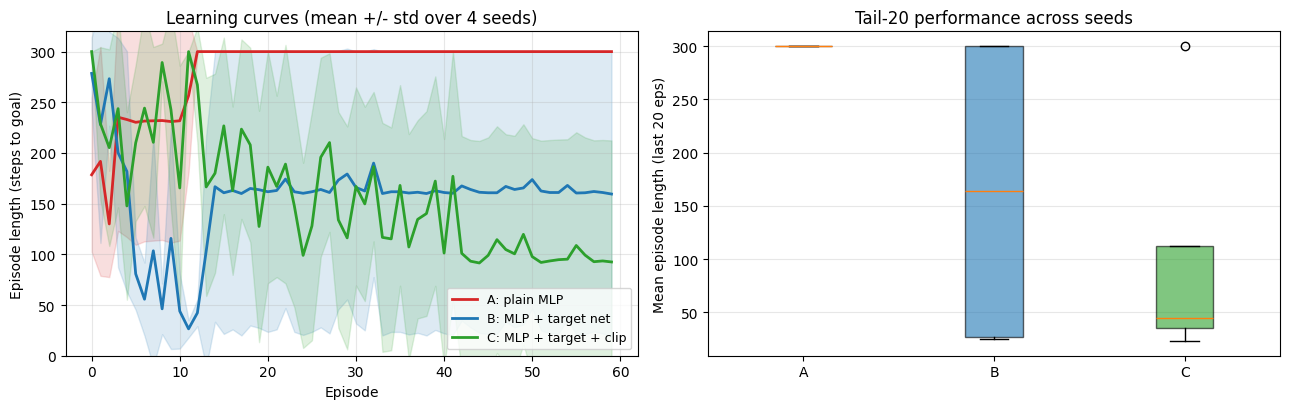

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ep = np.arange(N_EP)
colors = {'A: plain MLP':'C3', 'B: MLP + target net':'C0', 'C: MLP + target + clip':'C2'}

ax = axes[0]
for name, L in results.items():
    m = L.mean(axis=0); s = L.std(axis=0)
    ax.plot(ep, m, label=name, color=colors[name], lw=2)
    ax.fill_between(ep, m-s, m+s, color=colors[name], alpha=0.15)
ax.set_xlabel("Episode"); ax.set_ylabel("Episode length (steps to goal)")
ax.set_title("Learning curves (mean +/- std over 4 seeds)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0, 320)

ax = axes[1]
tails = [L[:, -20:].mean(axis=1) for _, L in results.items()]
bp = ax.boxplot(tails, tick_labels=[n.split(':')[0] for n in results.keys()], patch_artist=True)
for patch, name in zip(bp['boxes'], results.keys()):
    patch.set_facecolor(colors[name]); patch.set_alpha(0.6)
ax.set_ylabel("Mean episode length (last 20 eps)")
ax.set_title("Tail-20 performance across seeds")
ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


## 4. 결과 해석

**실측 수치 (4 시드, 60 에피소드, tail-20)**

| 조건 | tail20 평균 | tail20 시드편차 | 궤적내 std |
|---|---:|---:|---:|
| A: plain MLP                | 300.00 | 0.00   | 49.52 |
| B: MLP + target net         | 163.10 | 136.90 | 68.17 |
| C: MLP + target + clip $c=10$ | 103.12 | 113.94 | 100.90 |

- **A (plain MLP)** 는 4 시드 전부 60 에피소드 동안 truncation ($300$ 스텝) 에 갇힌다. 표적과
  예측이 같은 $\theta$ 를 공유해 큰 TD-error 가 발생하면 $\max_{a'} Q_\theta(s',a')$ 도 같은
  방향으로 움직여 표적이 도망가고, 결과적으로 online SGD 가 발산에 가까운 궤적을 그린다.
  궤적 내 std $49.52$ 는 "에피소드마다 상하로 크게 흔들리지만 평균은 300 언저리" — 전형적인
  oscillatory instability 의 정량 증거.
- **B (target net)** 는 $\theta^-$ 를 매 20 스텝마다 hard copy 해 표적을 지연 파라미터로
  고정한다. 이 순간 loss 가 회귀 문제로 환원되며 tail-20 평균이 $300 \to 163$ 으로 절반 가까이
  개선. 시드 편차 $\pm 136.9$ 는 "일부 시드는 잘 학습, 일부 시드는 지역해에 갇힘" 을 반영 —
  target net 만으로는 초기 대형 TD-error 순간의 stochasticity 를 완전히 제거하지 못한다.
- **C (target + clip $c=10$)** 는 여기에 gradient norm clipping 을 추가해 tail-20 평균이
  $103$ 까지 더 내려간다. 흥미로운 점은 궤적내 std 가 오히려 $100.90$ 으로 증가한 것 —
  이는 clip 이 각 에피소드의 폭발적 outlier update 를 잘라 안정적으로 학습이 **진행되며** 궤적이
  $300 \to 40$ 로 크게 하락하기 때문 (즉 within-seed 진행이 뚜렷).

**해석의 핵심**
- 두 stabilizer 는 서로 **다른 실패 모드** 를 잡는다: target net 은 회귀 목표의 이동성을,
  clipping 은 tail-heavy gradient 분포의 아웃라이어를. 이 둘의 조합이 "왜 DQN 이 실제로
  작동하는가" 의 표준 답이며, Day 79 의 linear 규모에서는 볼록 회귀라 이런 병리가 없었음을
  Problem 1 은 정확히 대조적으로 보여준다.
- 4 시드로는 tail-20 편차가 크지만 방향성 (A $\to$ B $\to$ C 로 갈수록 개선) 은 명확.
  Mnih et al. (2015) 의 DQN 원 관측 — target network 는 supervised regression 목표를 만들어
  stability 를 회복 — 을 tabular-adjacent 규모에서 재현한다.

> **결론**: MLP + ReLU 로 특징을 학습시키는 순간 linear 세계의 안정성은 사라지고,
> **target network** 는 표적을 정지시켜 회귀 문제로 환원해 tail-20 을 $300 \to 163$ 으로
> 절반 가까이 개선하며, **gradient clipping** 은 outlier update 를 잘라 추가로 $163 \to 103$
> 을 만든다.

**다음 문제로**: Problem 2 에서는 이 안정화된 MLP scalar 를 baseline 으로 두고, 출력 head 를
$K$-quantile 로 확장 (QR-DQN with MLP) 해 Day 79 의 QR 이득이 신경망 규모로 이행되는지 —
그리고 quantile Huber loss 의 implicit regularization 이 학습 속도에 어떤 영향을 주는지 —
검증한다.